In [1]:
!pip install roboflow torch torchvision matplotlib seaborn scikit-learn tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 60.0 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="qsoY2Xn003BKLD8IZ1y4")

# Insect (already working)
project1 = rf.workspace("drivermonitoringsystem-qcq2d").project("insect-pesticide")
dataset1 = project1.version(1).download("folder", overwrite=True)

# Fertilizer (FIX VERSION NUMBER)
project2 = rf.workspace("drivermonitoringsystem-qcq2d").project("crop-fertilizer")

dataset2 = project2.version(1).download("folder", overwrite=True)  # 🔥 change here

print(dataset2.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Insect-Pesticide-1 in folder:: 100%|██████████| 726/726 [00:00<00:00, 4333.00it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to Crop-Fertilizer-1 in folder:: 100%|██████████| 4273/4273 [00:00<00:00, 12335.12it/s]

/content/Crop-Fertilizer-1


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print("Insect:", os.listdir(dataset1.location))
print("Fertilizer:", os.listdir(dataset2.location))

print("Fertilizer classes:",
      os.listdir(dataset2.location + "/train"))

Insect: ['valid', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'train']
Fertilizer: ['valid', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'train']
Fertilizer classes: ['NeckBlast', 'False Smut Disease', 'Healthy Crop', 'Brown Spot Disease', 'Blast Disease', 'Bacterial Blight Disease']


In [5]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH_SIZE = 32

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3,0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def load_data(path):
    train = ImageFolder(path + "/train", transform=transform_train)
    valid = ImageFolder(path + "/valid", transform=transform_val)
    test  = ImageFolder(path + "/test", transform=transform_val)

    return (
        DataLoader(train, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(valid, batch_size=BATCH_SIZE),
        DataLoader(test, batch_size=BATCH_SIZE),
        train.classes
    )

train1, val1, test1, classes1 = load_data(dataset1.location)
train2, val2, test2, classes2 = load_data(dataset2.location)

In [6]:
import torchvision.models as models
import torch.nn as nn

def build_model(num_classes):
    model = models.resnet18(weights="IMAGENET1K_V1")

    # Freeze most layers
    for param in model.parameters():
        param.requires_grad = False

    # Train last block
    for param in model.layer4.parameters():
        param.requires_grad = True

    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )

    return model.to(device)

model1 = build_model(len(classes1))   # Insect
model2 = build_model(len(classes2))   # Fertilizer

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 212MB/s]


In [7]:
import torch.optim as optim
from tqdm import tqdm

def train_model(model, train_loader, val_loader, epochs, save_path, lr):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    best_acc = 0

    for epoch in range(epochs):
        model.train()

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, pred = torch.max(outputs, 1)

                correct += (pred == labels).sum().item()
                total += labels.size(0)

        acc = 100 * correct / total
        print(f"Epoch {epoch+1} → Accuracy: {acc:.2f}%")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), save_path)

    print("Best Accuracy:", best_acc)

In [8]:
# 🐛 Insect
train_model(model1, train1, val1,
            epochs=60,
            save_path="/content/insect_resnet18.pth",
            lr=0.001)

# 🌱 Fertilizer
train_model(model2, train2, val2,
            epochs=30,
            save_path="/content/fertilizer_resnet18.pth",
            lr=0.0003)

100%|██████████| 20/20 [00:05<00:00,  3.94it/s]


Epoch 1 → Accuracy: 70.69%


100%|██████████| 20/20 [00:02<00:00,  9.75it/s]


Epoch 2 → Accuracy: 77.59%


100%|██████████| 20/20 [00:02<00:00,  9.94it/s]


...

Epoch 28 → Accuracy: 85.95%


100%|██████████| 94/94 [00:10<00:00,  8.66it/s]


Epoch 29 → Accuracy: 85.71%


100%|██████████| 94/94 [00:10<00:00,  8.79it/s]


Epoch 30 → Accuracy: 85.95%
Best Accuracy: 87.23653395784544


In [9]:
from sklearn.metrics import accuracy_score

def test_model(model, loader):
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            _, p = torch.max(out, 1)

            preds.extend(p.cpu().numpy())
            labels_all.extend(y.numpy())

    print("Test Accuracy:", accuracy_score(labels_all, preds))

test_model(model1, test1)
test_model(model2, test2)

Test Accuracy: 0.6
Test Accuracy: 0.8454332552693209


In [10]:
def plot_confusion_matrix(model, test_loader, class_names, title, filename):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    import torch

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # ✅ Save to Drive
    save_path = f"{SAVE_DIR}/{filename}"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    print(f"Saved: {save_path}")
    plt.show()

In [16]:
def plot_tsne(model, test_loader, class_names, title, filename):
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt
    import numpy as np
    import torch

    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
    feature_extractor.eval().to(device)

    features, labels_list = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            feats = feature_extractor(images).squeeze()
            features.append(feats.cpu().numpy())
            labels_list.extend(labels.numpy())

    features = np.vstack(features)

    # 🔥 AUTO FIX PERPLEXITY
    n_samples = len(features)
    perplexity = min(30, n_samples - 1)

    print(f"Samples: {n_samples}, Using perplexity: {perplexity}")

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    reduced = tsne.fit_transform(features)

    plt.figure(figsize=(8,6))

    for i, cls in enumerate(class_names):
        idx = np.array(labels_list) == i
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=cls)

    plt.legend()
    plt.title(title)

    # Save
    save_path = f"{SAVE_DIR}/{filename}"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    print(f"Saved: {save_path}")
    plt.show()

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os

SAVE_DIR = "/content/drive/MyDrive/model_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

Saved: /content/drive/MyDrive/model_outputs/insect_cm.png


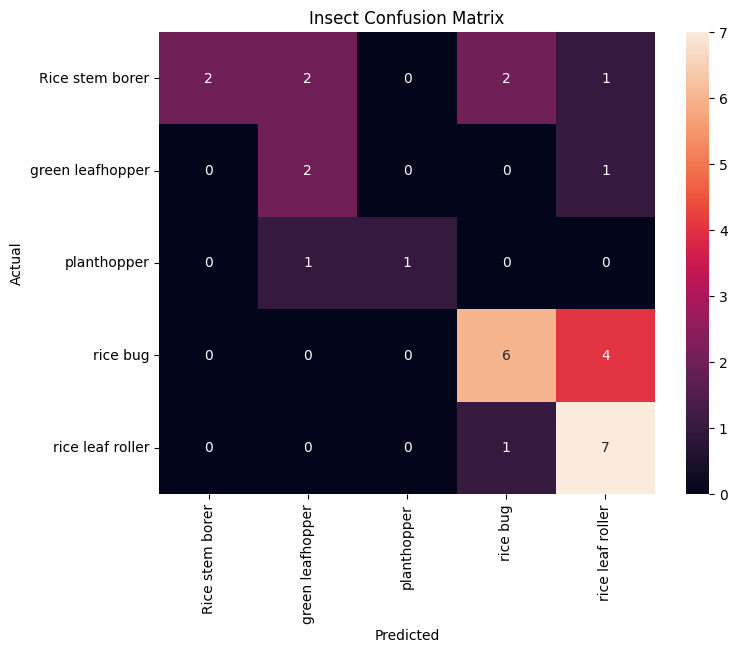

Samples: 30, Using perplexity: 29
Saved: /content/drive/MyDrive/model_outputs/insect_tsne.png


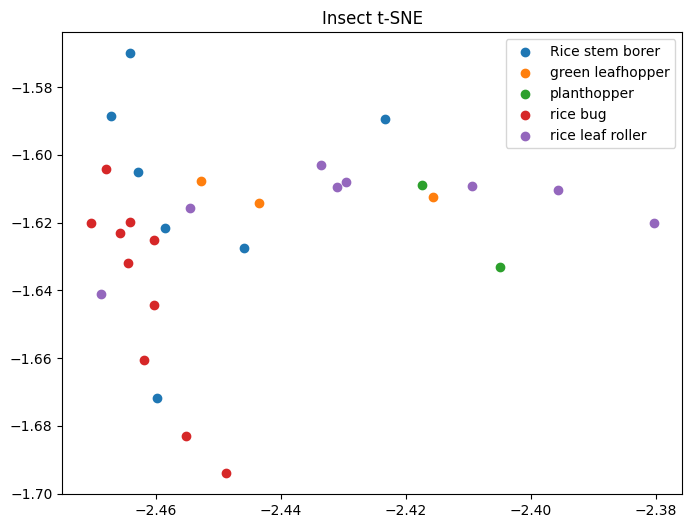

Saved: /content/drive/MyDrive/model_outputs/fertilizer_cm.png


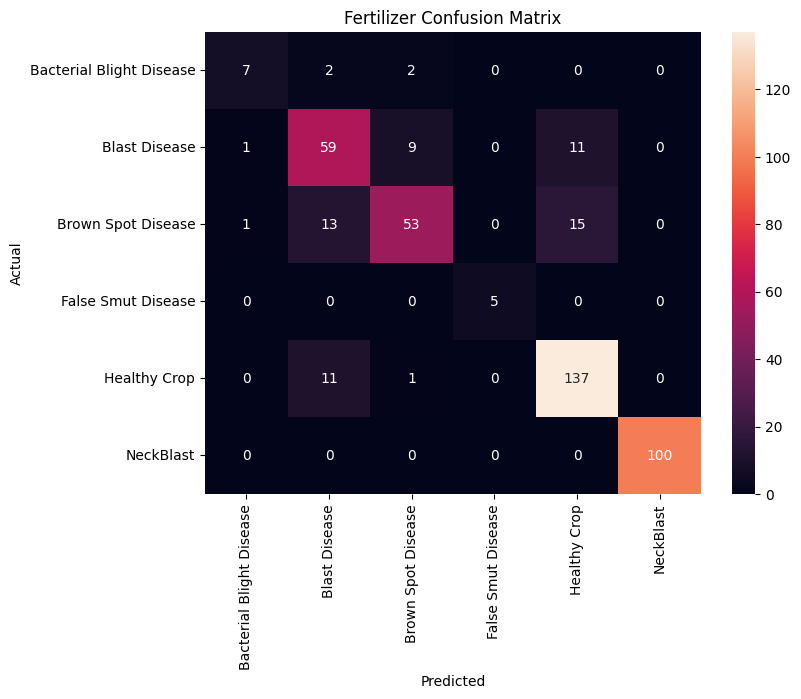

Samples: 427, Using perplexity: 30
Saved: /content/drive/MyDrive/model_outputs/fertilizer_tsne.png


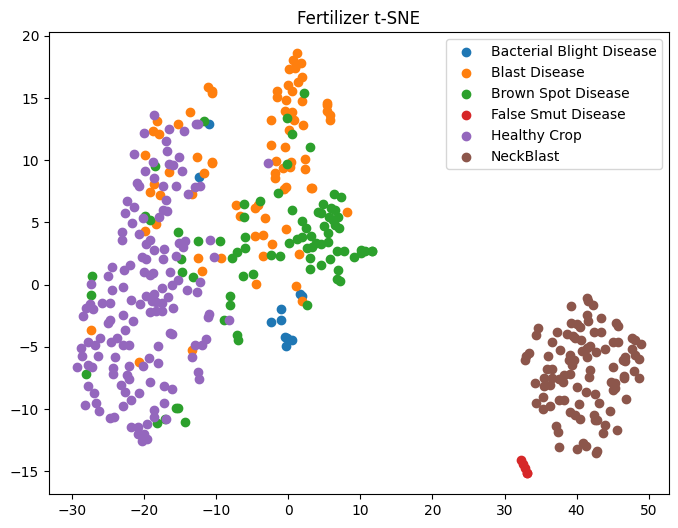

In [19]:
# Insect
plot_confusion_matrix(model1, test1, classes1,
                      "Insect Confusion Matrix",
                      "insect_cm.png")

plot_tsne(model1, test1, classes1,
          "Insect t-SNE",
          "insect_tsne.png")


# Fertilizer
plot_confusion_matrix(model2, test2, classes2,
                      "Fertilizer Confusion Matrix",
                      "fertilizer_cm.png")

plot_tsne(model2, test2, classes2,
          "Fertilizer t-SNE",
          "fertilizer_tsne.png")

In [21]:
# Save models (safe)
torch.save(model1.state_dict(), "/content/insect_resnet18.pth")
torch.save(model2.state_dict(), "/content/fertilizer_resnet18.pth")

# Copy to Drive
import shutil

shutil.copy("/content/insect_resnet18.pth",
            "/content/drive/MyDrive/insect_resnet18.pth")

shutil.copy("/content/fertilizer_resnet18.pth",
            "/content/drive/MyDrive/fertilizer_resnet18.pth")

print("Saved to Drive ✅")

Saved to Drive ✅


In [27]:
from sklearn.metrics import accuracy_score

def test_model(model, loader):
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            _, p = torch.max(out, 1)

            preds.extend(p.cpu().numpy())
            labels_all.extend(y.numpy())

    print("Test Accuracy:", accuracy_score(labels_all, preds))

test_model(model1, test1)
test_model(model2, test2)

Test Accuracy: 0.6
Test Accuracy: 0.8454332552693209


In [48]:
def train_model_with_history(model, train_loader, val_loader, epochs, save_path, lr):
    import torch.optim as optim
    import torch.nn as nn

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    train_losses = []
    val_losses = []
    val_accuracies = []

    best_acc = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        correct, total = 0, 0
        val_loss_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                loss = criterion(outputs, labels)
                val_loss_total += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        acc = 100 * correct / total

        val_losses.append(val_loss)
        val_accuracies.append(acc)

        print(f"Epoch {epoch+1} → Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {acc:.2f}%")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), save_path)

    print("Best Accuracy:", best_acc)

    return train_losses, val_losses, val_accuracies

In [49]:
# Insect
train_loss1, val_loss1, val_acc1 = train_model_with_history(
    model1, train1, val1, 60,
    "/content/insect_resnet18.pth", lr=0.001
)

# Fertilizer
train_loss2, val_loss2, val_acc2 = train_model_with_history(
    model2, train2, val2, 30,
    "/content/fertilizer_resnet18.pth", lr=0.0003
)

Epoch 1 → Train Loss: 0.0474 | Val Loss: 1.5960 | Acc: 82.76%
Epoch 2 → Train Loss: 0.0765 | Val Loss: 1.6165 | Acc: 79.31%
Epoch 3 → Train Loss: 0.0610 | Val Loss: 1.3861 | Acc: 81.03%
Epoch 4 → Train Loss: 0.0318 | Val Loss: 1.1419 | Acc: 82.76%
Epoch 5 → Train Loss: 0.0132 | Val Loss: 1.0690 | Acc: 82.76%
Epoch 6 → Train Loss: 0.0031 | Val Loss: 1.0394 | Acc: 86.21%
Epoch 7 → Train Loss: 0.0027 | Val Loss: 0.9485 | Acc: 86.21%
Epoch 8 → Train Loss: 0.0019 | Val Loss: 0.9986 | Acc: 86.21%
Epoch 9 → Train Loss: 0.0124 | Val Loss: 0.8688 | Acc: 75.86%
Epoch 10 → Train Loss: 0.0154 | Val Loss: 0.8001 | Acc: 81.03%
Epoch 11 → Train Loss: 0.0214 | Val Loss: 1.2151 | Acc: 86.21%
Epoch 12 → Train Loss: 0.0434 | Val Loss: 1.0753 | Acc: 82.76%
Epoch 13 → Train Loss: 0.0320 | Val Loss: 1.5340 | Acc: 74.14%
Epoch 14 → Train Loss: 0.0873 | Val Loss: 1.0223 | Acc: 79.31%
Epoch 15 → Train Loss: 0.0593 | Val Loss: 0.9940 | Acc: 77.59%
Epoch 16 → Train Loss: 0.0669 | Val Loss: 0.6949 | Acc: 84.48%
E

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import matplotlib.pyplot as plt
import os

SAVE_DIR = "/content/drive/MyDrive/model_graphs"
os.makedirs(SAVE_DIR, exist_ok=True)

def plot_graph(train_loss, val_loss, val_acc, title, filename):

    plt.figure(figsize=(18,5))

    # Training loss
    plt.subplot(1,3,1)
    plt.plot(train_loss)
    plt.title("Training Loss")
    plt.xlabel("Epoch")

    # Validation loss
    plt.subplot(1,3,2)
    plt.plot(val_loss)
    plt.title("Validation Loss")
    plt.xlabel("Epoch")

    # Validation accuracy
    plt.subplot(1,3,3)
    plt.plot(val_acc)
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")

    plt.suptitle(title)

    save_path = f"{SAVE_DIR}/{filename}"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    print("Saved to:", save_path)
    plt.show()

Saved to: /content/drive/MyDrive/model_graphs/insect_graph.png


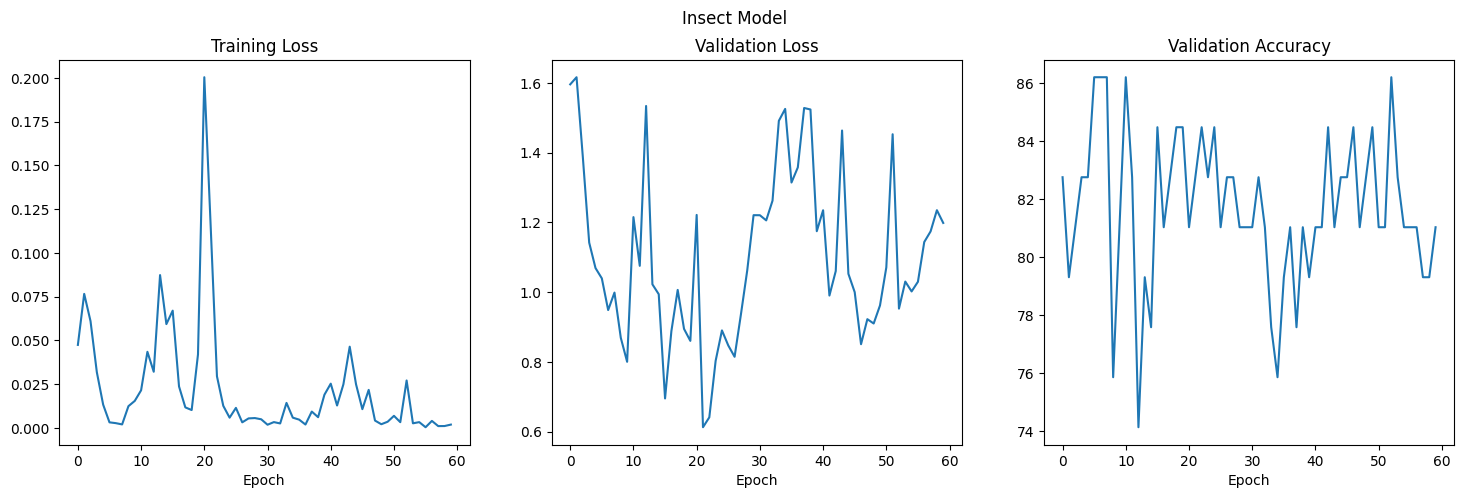

Saved to: /content/drive/MyDrive/model_graphs/fertilizer_graph.png


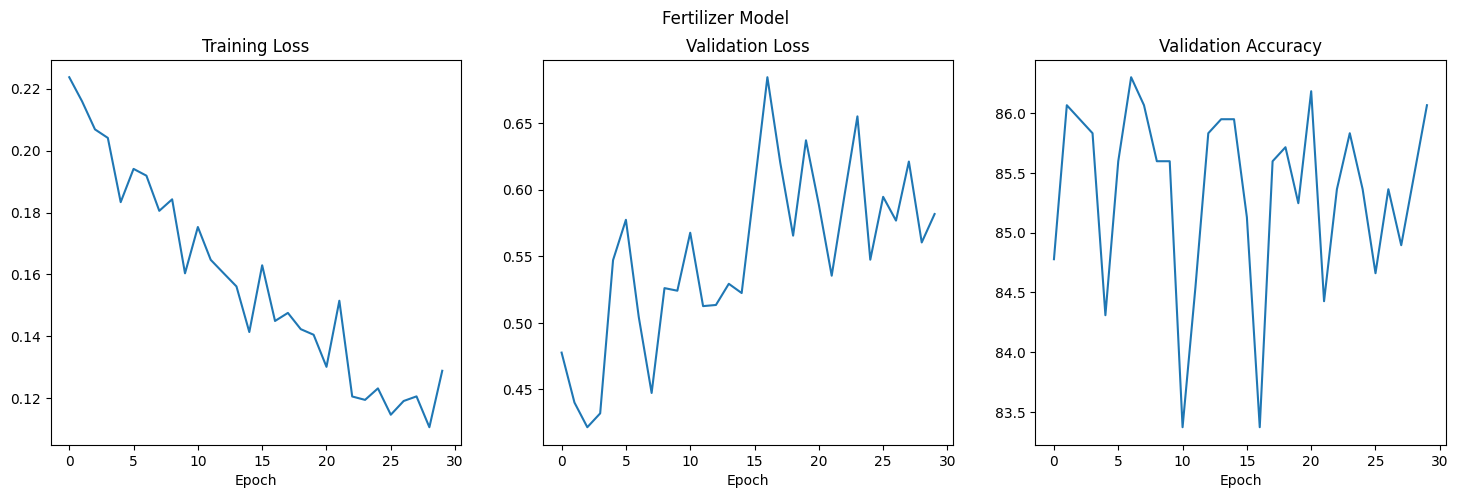

In [52]:
# Insect graph
plot_graph(train_loss1, val_loss1, val_acc1,
           "Insect Model",
           "insect_graph.png")

# Fertilizer graph
plot_graph(train_loss2, val_loss2, val_acc2,
           "Fertilizer Model",
           "fertilizer_graph.png")